In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the dataset credit_default from the UCI Machine Learning Repository
credit_default = fetch_ucirepo(id=350)

In [3]:
X = credit_default.data.features
Y = credit_default.data.targets

In [4]:
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [5]:
Y.head()

,Y
0,1
1,1
2,0
3,0
4,0


In [6]:
df = pd.concat([X, Y], axis=1)

In [7]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [8]:
credit_default.variables

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,NaN,NaN,None,no
1,X1,Feature,Integer,NaN,LIMIT_BAL,None,no
2,X2,Feature,Integer,Sex,SEX,None,no
3,X3,Feature,Integer,Education Level,EDUCATION,None,no
4,X4,Feature,Integer,Marital Status,MARRIAGE,None,no
5,X5,Feature,Integer,Age,AGE,None,no
6,X6,Feature,Integer,NaN,PAY_0,None,no
7,X7,Feature,Integer,NaN,PAY_2,None,no
8,X8,Feature,Integer,NaN,PAY_3,None,no
9,X9,Feature,Integer,NaN,PAY_4,None,no


In [9]:
rename_columns = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
    "Y": "DEFAULT_PAYMENT_NEXT_MONTH"
}

df = df.rename(columns=rename_columns)

In [10]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_PAYMENT_NEXT_MONTH
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 1. Dataset Overview

The dataset contains historical credit card customer information,
including demographic attributes, credit limits, repayment status,
bill amounts, and payment amounts.

The target variable `DEFAULT` indicates whether a customer defaults
on payment in the following month.

The dataset contains 30,000 customer records and 23 input features.

### Feature Description

#### Customer Information

- `LIMIT_BAL`: Amount of credit granted to the customer, measured in New Taiwan Dollars (NT$).

- `SEX`: Customer gender.
  - `1` = Male
  - `2` = Female

- `EDUCATION`: Customer education level.
  - `1` = Graduate school
  - `2` = University
  - `3` = High school
  - `4` = Others

- `MARRIAGE`: Customer marital status.
  - `1` = Married
  - `2` = Single
  - `3` = Others

- `AGE`: Customer age in years.

#### Repayment History

The variables `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5`, and `PAY_6`
represent the customer's repayment status over the previous six months.

- `PAY_0`: Repayment status in September 2005
- `PAY_2`: Repayment status in August 2005
- `PAY_3`: Repayment status in July 2005
- `PAY_4`: Repayment status in June 2005
- `PAY_5`: Repayment status in May 2005
- `PAY_6`: Repayment status in April 2005

According to the dataset documentation:

- `-1` = Payment made on time
- `1` = Payment delayed by one month
- `2` = Payment delayed by two months
- ...
- `8` = Payment delayed by eight months
- `9` = Payment delayed by nine months or more

Some records also contain values such as `-2` and `0`.
These values are not clearly defined in the official dataset documentation
and should therefore be investigated during the data cleaning stage.

#### Bill Statement Amount

These variables represent the amount of the customer's monthly credit card bill:

- `BILL_AMT1`: Bill amount in September 2005
- `BILL_AMT2`: Bill amount in August 2005
- `BILL_AMT3`: Bill amount in July 2005
- `BILL_AMT4`: Bill amount in June 2005
- `BILL_AMT5`: Bill amount in May 2005
- `BILL_AMT6`: Bill amount in April 2005

All amounts are measured in New Taiwan Dollars (NT$).

#### Previous Payment Amount

These variables represent the amount actually paid by the customer:

- `PAY_AMT1`: Payment amount in September 2005
- `PAY_AMT2`: Payment amount in August 2005
- `PAY_AMT3`: Payment amount in July 2005
- `PAY_AMT4`: Payment amount in June 2005
- `PAY_AMT5`: Payment amount in May 2005
- `PAY_AMT6`: Payment amount in April 2005

#### Target Variable

- `DEFAULT`
  - `0` = Customer did not default on payment
  - `1` = Customer defaulted on payment

The objective of the project is to build a machine learning model that
estimates the probability that a customer will default in the following month.

In [11]:
df.shape

(30000, 24)

In [12]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_PAYMENT_NEXT_MONTH
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_AMT4        

In [14]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_PAYMENT_NEXT_MONTH
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [15]:
df.dtypes

LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
DEFAULT_PAYMENT_NEXT_MONTH    int64
dtype: object

In [16]:
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
DEFAULT_PAYMENT_NEXT_MONTH    0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(35)

In [18]:
df["DEFAULT_PAYMENT_NEXT_MONTH"].value_counts()

DEFAULT_PAYMENT_NEXT_MONTH
0    23364
1     6636
Name: count, dtype: int64

In [19]:
df["DEFAULT_PAYMENT_NEXT_MONTH"].value_counts(normalize=True)*100

DEFAULT_PAYMENT_NEXT_MONTH
0    77.88
1    22.12
Name: proportion, dtype: float64

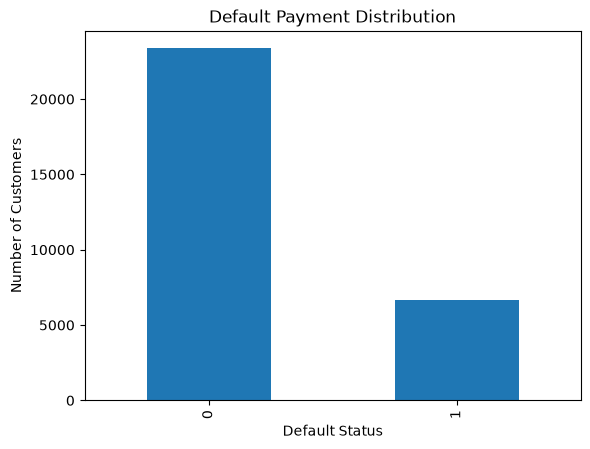

In [20]:
df["DEFAULT_PAYMENT_NEXT_MONTH"].value_counts().plot(
    kind="bar"
)

plt.title("Default Payment Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")
plt.show()

## 2. Detailed Data Understanding

This section examines the structure, data types, unique values,
missing values, and potential data quality issues of each feature
before performing data cleaning and feature engineering.

In [21]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "missing": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2)
})

summary

,dtype,n_unique,missing,missing_pct
LIMIT_BAL,int64,81,0,0.0
SEX,int64,2,0,0.0
EDUCATION,int64,7,0,0.0
MARRIAGE,int64,4,0,0.0
AGE,int64,56,0,0.0
PAY_0,int64,11,0,0.0
PAY_2,int64,11,0,0.0
PAY_3,int64,11,0,0.0
PAY_4,int64,11,0,0.0
PAY_5,int64,10,0,0.0


In [22]:
demographic_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE"
]

repayment_status_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

bill_cols = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

payment_cols = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

In [23]:
df["SEX"].value_counts().sort_index()

SEX
1    11888
2    18112
Name: count, dtype: int64

### SEX - Findings

**Observation:**  
The `SEX` feature contains only the expected values:
- `1` = Male
- `2` = Female

**Decision:** KEEP

The feature does not contain unexpected categories or missing values.

**Planned Action:**  
Keep the feature for modeling. It should be treated as a categorical feature rather than a continuous numerical variable.

In [24]:
df["EDUCATION"].value_counts().sort_index()

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

### EDUCATION - Findings

**Observation:**  
The `EDUCATION` feature is officially defined with four categories:
- `1` = Graduate school
- `2` = University
- `3` = High school
- `4` = Others

However, the dataset also contains undocumented values `0`, `5`, and `6`.

**Decision:** CLEAN

The undocumented categories require preprocessing before modeling.

**Planned Action:**  
Merge categories `0`, `5`, and `6` into category `4` (`Others`) during the data cleaning stage.

In [25]:
df["MARRIAGE"].value_counts().sort_index()

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

### MARRIAGE - Findings

**Observation:**  
The expected categories are:
- `1` = Married
- `2` = Single
- `3` = Others

The dataset also contains category `0`, which is not defined in the dataset documentation.

**Decision:** CLEAN

Category `0` should not remain as a separate unexplained category.

**Planned Action:**  
Merge category `0` into category `3` (`Others`) during data cleaning.

In [26]:
df["AGE"].describe()

count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

In [27]:
df["AGE"].sort_values().head(10)

7141     21
27662    21
8490     21
12556    21
1471     21
7183     21
27630    21
15728    21
6733     21
15725    21
Name: AGE, dtype: int64

In [28]:
df["AGE"].sort_values(ascending=False).head(10)

18245    79
25136    75
25141    75
246      75
29175    74
29179    73
29163    73
10699    73
387      73
1644     72
Name: AGE, dtype: int64

### AGE - Findings

**Observation:**  
The values of `AGE` fall within a reasonable range and no invalid values such as negative ages or zero were identified.

**Decision:** KEEP

The feature appears to be valid and potentially useful for predicting default risk.

**Planned Action:**  
Keep the original feature. Age groups may be created later during feature engineering if they provide additional predictive value.

In [29]:
df["LIMIT_BAL"].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

In [30]:
df["LIMIT_BAL"].value_counts().sort_index().head(20)

LIMIT_BAL
10000      493
16000        2
20000     1976
30000     1610
40000      230
50000     3365
60000      825
70000      731
80000     1567
90000      651
100000    1048
110000     588
120000     726
130000     729
140000     749
150000    1110
160000     694
170000     532
180000     995
190000     229
Name: count, dtype: int64

In [31]:
(df["LIMIT_BAL"] <= 0).sum()

np.int64(0)

### LIMIT_BAL - Findings

**Observation:**  
The credit limit values are positive and no clearly invalid values were identified.

Some customers have much higher credit limits than others, but these values may represent valid high-credit customers rather than data errors.

**Decision:** KEEP

**Planned Action:**  
Keep the feature and investigate its distribution and potential skewness during EDA.

In [32]:
for col in repayment_status_cols:
    print(df[col].value_counts().sort_index())

PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64


### Repayment Status - Findings

**Observation:**  
The repayment status variables contain values ranging from negative values to positive delay values.

Positive values represent the number of months of payment delay.

Special values such as `-2`, `-1`, and `0` are also present and require careful interpretation.

**Decision:** KEEP AND INVESTIGATE

These variables contain important information about customer repayment behavior and should not be removed.

**Planned Action:**  
Preserve the original values for now and investigate the meaning and distribution of the special repayment codes before applying any transformation.

In [33]:
df[bill_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0


In [34]:
(df[bill_cols] < 0).sum()

BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688
dtype: int64

### Bill Amount - Findings

**Observation:**  
The bill amount variables contain a wide range of values, including some negative amounts.

Negative bill amounts are not necessarily data errors and may represent credit balances or overpayments.

**Decision:** KEEP

**Planned Action:**  
Keep the original values and investigate their distributions and extreme values during EDA. Negative values will not be removed automatically.

In [35]:
df[payment_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0
PAY_AMT3,30000.0,5225.681500,17606.961470,0.0,390.00,1800.0,4505.00,896040.0
PAY_AMT4,30000.0,4826.076867,15666.159744,0.0,296.00,1500.0,4013.25,621000.0
PAY_AMT5,30000.0,4799.387633,15278.305679,0.0,252.50,1500.0,4031.50,426529.0
PAY_AMT6,30000.0,5215.502567,17777.465775,0.0,117.75,1500.0,4000.00,528666.0


In [36]:
(df[payment_cols] < 0).sum()

PAY_AMT1    0
PAY_AMT2    0
PAY_AMT3    0
PAY_AMT4    0
PAY_AMT5    0
PAY_AMT6    0
dtype: int64

### Payment Amount - Findings

**Observation:**  
The payment amount variables contain non-negative values.

A payment amount of `0` may indicate that the customer made no payment during that month and therefore represents meaningful behavior rather than missing data.

**Decision:** KEEP

**Planned Action:**  
Keep zero payment values and investigate the distribution and extreme payment amounts during EDA.

In [37]:
df["DEFAULT_PAYMENT_NEXT_MONTH"].value_counts()

DEFAULT_PAYMENT_NEXT_MONTH
0    23364
1     6636
Name: count, dtype: int64

In [38]:
df["DEFAULT_PAYMENT_NEXT_MONTH"].value_counts(normalize=True).mul(100).round(2)

DEFAULT_PAYMENT_NEXT_MONTH
0    77.88
1    22.12
Name: proportion, dtype: float64

### DEFAULT - Findings

**Observation:**  
The target variable contains two valid classes:
- `0` = No default
- `1` = Default

The two classes are not equally distributed, with non-default customers representing the majority of observations.

**Decision:** KEEP

The target variable is valid for the binary classification problem.

**Planned Action:**  
The class imbalance will be considered during model evaluation and training. Metrics such as Precision, Recall, F1-score, and PR-AUC will be used instead of relying only on Accuracy.

In [39]:
df.duplicated().sum()

np.int64(35)

### Duplicate Records - Findings

**Observation:**  
Potential duplicate rows were identified.

However, duplicate feature values do not necessarily mean that the records belong to the same customer, especially because the customer identifier is not included in the current feature set.

**Decision:** INVESTIGATE

**Planned Action:**  
Do not remove duplicate rows automatically. Their origin should be investigated before deciding whether they represent true duplicate records.

In [40]:
#export the cleaned dataset to a CSV file
df.to_csv(
    "../data/raw/credit_default_raw.csv",
    index=False
)